In [9]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error as MSE
from sklearn.ensemble import BaggingClassifier , AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosted Trees
- Each predictor in the ensemble corrects to its predecessor's error.
- In contrast to Adaboost , the weights of the training instances are not tweaked .
- Instead each predictor is trained using the residual errors of its predecessor as labels
![2.png](attachment:2.png)

- The ensemble consists of **N** trees . Tree1 is trained using the features matrix X and the dataset labels y
- The predictions labels y1^ are used to determine the training set residual errors r1. 
- Tree2 is then trained using the features matrix X and the residual r1^ are then used to determine the residuals of residuals which are labelled r2 
- This process is repeated until all of the N trees forming the ensemble are trained

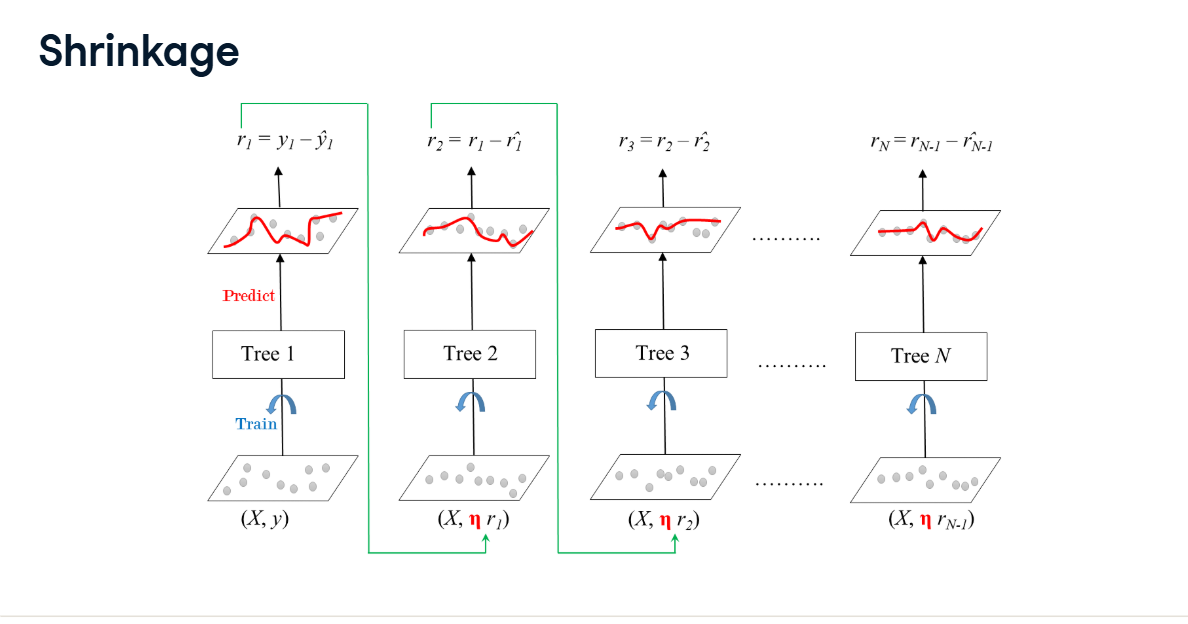

- An important parameter used in training gradient boosted trees is shrinkage
- In this context , shrinkage refers to the fact that the prediction of each tree is ensemble is shrinked after it is multiplied by a learning rate **η** which is number betwen 0 and 1
- Similarly to Adaboost , there's is a trade-off between **η** and the number of estimators.
- Decreasing the learning rate needs to be compensated by increasing the number of estimators in order for ensemble to reach a certain performace


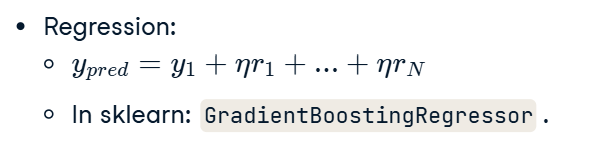


# Gradient Boosted Trees : Prediction
- Once all trees in the ensemble are trained , predictions can be made.
- When a new instance is available each tree predicts a label and the final ensemble prediction is given by the formula shown on this slide.

In [7]:
csv_file_path = "output_data.csv"

df_csv = pd.read_csv("../../1. Classification and Regression Trees/Regression/output_data.csv")

df_csv = df_csv.drop(["car_name","model_year","origin"],axis=1)

df_csv['horsepower'] = pd.to_numeric(df_csv['horsepower'], errors='coerce')
print(df_csv.head())
print(df_csv.info())

    mpg  cylinders  displacement  horsepower  weight  acceleration
0  18.0          8         307.0       130.0  3504.0          12.0
1  15.0          8         350.0       165.0  3693.0          11.5
2  18.0          8         318.0       150.0  3436.0          11.0
3  16.0          8         304.0       150.0  3433.0          12.0
4  17.0          8         302.0       140.0  3449.0          10.5
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 18.8 KB
None


In [12]:
feature = df_csv.drop("mpg",axis=1).values
target = df_csv['mpg'].values

df_csv.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 18.8 KB


In [24]:
from sklearn.impute import SimpleImputer

X_train , X_test , y_train , y_test = train_test_split(feature,target,test_size=0.3,random_state=1)

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

gbt = GradientBoostingRegressor(n_estimators=150,max_depth=4,random_state=1)

gbt.fit(X_train,y_train)

y_pred = gbt.predict(X_test)

mse_test = MSE(y_test,y_pred)

rmse_test = mse_test ** 0.5

print("Test set RMSE : {:.2f}".format(rmse_test))
print("Test set MSE : {:.2f}".format(mse_test))

print(np.min(target))
print(np.max(target))

Test set RMSE : 3.48
Test set MSE : 12.10
9.0
46.6
